# Real pretrained Gemma 4: attribution, readouts and controlled interventions

This notebook runs **google/gemma-4-E2B**, revision `d29ff6b45f081a49ee2733a859c9c9c2d95d1a6f`, using the original BF16 text weights. It does not substitute a random transformer or quantize the weights.

**Machine profile:** RTX 3080 10GB plus host RAM. A ~4.70GB per-layer embedding table is computed on CPU; only gathered rows move to GPU. The rest of the text model runs on GPU. The downloaded official checkpoint is ~10.25GB and is reused from the Hugging Face cache.

Use the dedicated `.[pretrained,notebooks]` CUDA environment described in `docs/pretrained.md`. Prepare the cache explicitly with `python scripts/run_gemma4_example.py --allow-download --output /tmp/my-first-gemma4-run.json`. This notebook itself is **cache-only** and makes no LLM API calls. Restart the kernel before rerunning all cells so a previous model does not occupy VRAM.

**Question:** How do token sensitivities and post-block residual interventions behave for three predefined capital-city contrasts? We retain failures and distinguish a nontrivial earlier-layer intervention from copying a final answer readout.

In [1]:
import os, time, json, resource, sys
os.environ.setdefault("USE_TF", "0")
os.environ["HF_HUB_OFFLINE"] = "1"
import torch, pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import display, JSON
from autoexplain.pretrained import load_gemma4
from autoexplain.pretrained_study import run_pretrained_study
torch.set_num_threads(2)
torch.manual_seed(7)
assert torch.cuda.is_available(), "Use the dedicated CUDA environment; no silent CPU/random fallback."
torch.cuda.reset_peak_memory_stats()
started = time.perf_counter()
print("GPU:", torch.cuda.get_device_name(0), "| PyTorch:", torch.__version__)


GPU: NVIDIA GeForce RTX 3080 | PyTorch: 2.10.0+cu126


## 1. Load the actual checkpoint

The loader remaps the multimodal checkpoint's text keys, refuses missing text weights, and deliberately excludes audio/vision parameters. It checks available host/GPU memory before placement. A tiny native-checkpoint regression test verifies the key mapping and a CUDA test compares split versus native placement.

Gemma 4 has **two token-embedding routes**. The experiment retains both routes rather than pretending that a single `inputs_embeds` substitution accounts for all token identity.

In [2]:
bundle = load_gemma4(allow_download=False)
display(JSON(bundle.metadata, expanded=True))


/home/ptthang/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<IPython.core.display.JSON object>

## 2. Run every predefined case and check behavior first

The clean/recipient prompts differ at exactly one aligned country token. The fixed pairs are France/Germany, Italy/Spain, and Japan/China. These are illustrative cases, not a population benchmark. A positive margin means the donor answer is preferred to the recipient answer; it does not necessarily mean the donor answer ranks first in the entire vocabulary.

In [3]:
report = run_pretrained_study(bundle)
behavior = []
for pair in report["pairs"]:
    behavior.append({
        "clean": pair["clean_prompt"], "clean top1": pair["clean_top5"][0]["text"],
        "expected clean top1": pair["clean_target_is_top1"],
        "recipient": pair["recipient_prompt"], "recipient top1": pair["recipient_top5"][0]["text"],
        "expected recipient top1": pair["recipient_foil_is_top1"],
        "clean margin": pair["clean_margin"], "recipient margin": pair["recipient_margin"]
    })
display(pd.DataFrame(behavior))
print("Measured experimental computation seconds:", report["experiment_seconds"])


,clean,clean top1,expected clean top1,recipient,recipient top1,expected recipient top1,clean margin,recipient margin
0,The capital of France is,Paris,True,The capital of Germany is,Berlin,True,8.3125,-7.125
1,The capital of Italy is,Rome,True,The capital of Spain is,Madrid,True,7.0000,-7.500
2,The capital of Japan is,Tokyo,True,The capital of China is,Beijing,True,6.9375,-5.875


Measured experimental computation seconds: 4.055171023006551


## 3. Token attribution through both embedding routes

Signed gradient×activation is shown separately for the main embedding and the per-layer embedding table. The score is the **donor-answer minus recipient-answer logit margin**, evaluated on the clean prompt. These are local, route-conditional sensitivities. Their signs and scales are not a completeness-certified decomposition of the answer, and they should not be read as causal truth.

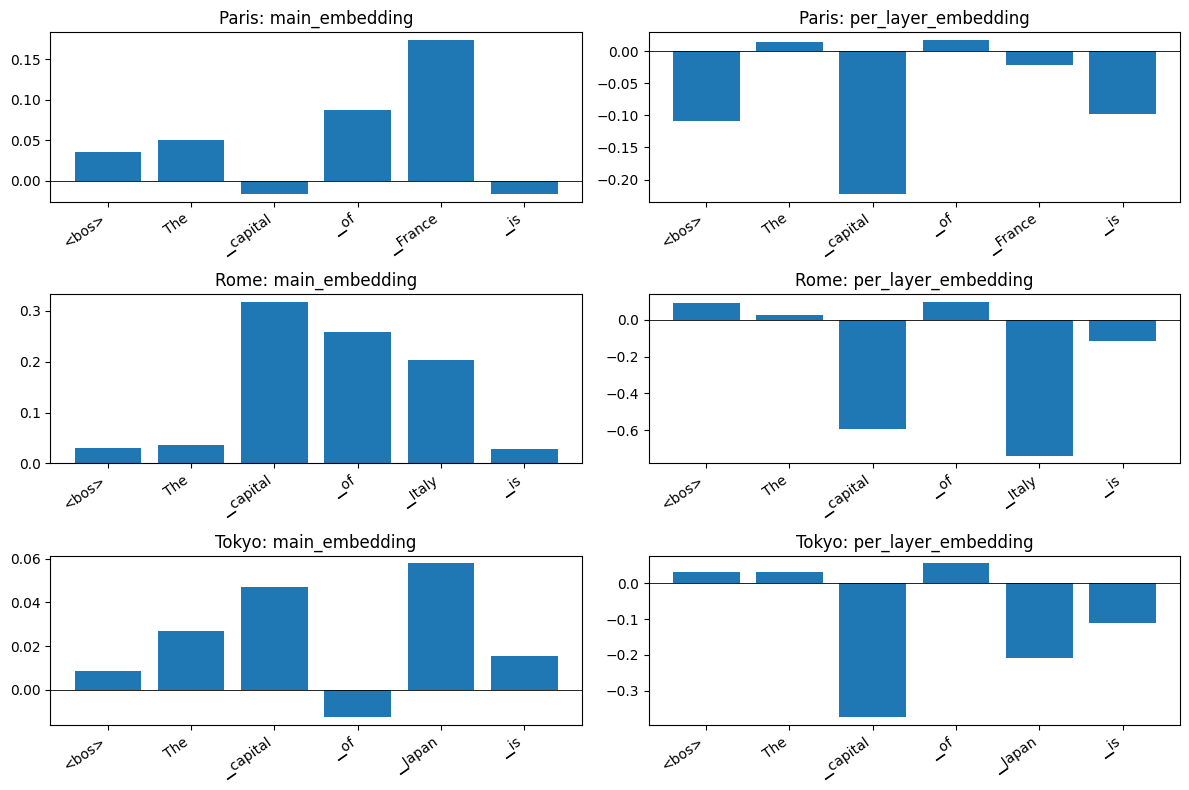

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for row, pair in enumerate(report["pairs"]):
    labels = pair["token_labels"]
    for col, route in enumerate(["main_embedding", "per_layer_embedding"]):
        values = pair["embedding_attribution"][route]["gradient_x_activation"]
        axes[row, col].bar(range(len(values)), values)
        axes[row, col].set_xticks(range(len(values)), labels, rotation=35, ha="right")
        axes[row, col].axhline(0, color="black", linewidth=.6)
        axes[row, col].set_title(pair["target"].strip() + ": " + route)
plt.tight_layout(); plt.show()


## 4. Plain logit-lens readouts

Read each selected post-block residual with the model's final RMSNorm, unembedding, **and logit softcap**. This is ordinary logit lens, not a fitted Jacobian lens. The final-layer readout must agree with the actual output; earlier layers are provisional readouts, not statements that the model has already committed to an answer.

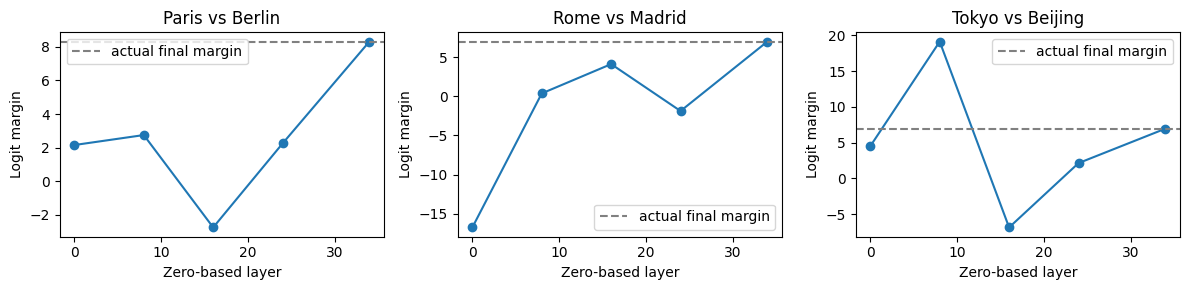

Final readout errors: [0.0, 0.0, 0.0]


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, pair in zip(axes, report["pairs"]):
    ax.plot([x["layer"] for x in pair["readouts"]], [x["margin"] for x in pair["readouts"]], marker="o")
    ax.axhline(pair["clean_margin"], color="gray", linestyle="--", label="actual final margin")
    ax.set_title(pair["target"].strip() + " vs " + pair["foil"].strip())
    ax.set_xlabel("Zero-based layer"); ax.set_ylabel("Logit margin"); ax.legend()
plt.tight_layout(); plt.show()
print("Final readout errors:", [p["final_readout_margin_error"] for p in report["pairs"]])


## 5. Donor patches against self and norm-matched random controls

At each selected layer, patch either the changed-country position or the last position. Three random directions match the donor-minus-recipient activation norm at that position. Error bars below are the **sample standard deviation of three controls**, not confidence intervals.

Token IDs, per-layer token identity and shared-KV paths remain otherwise unchanged. A post-block residual intervention does not replace those other paths. The last-token patch at the final layer is an intentionally **trivial positive control**: it copies the donor answer readout, so it cannot establish circuit discovery.

The complete table below retains all positions, layers and prompt pairs, including interventions that do nothing or fail to make the donor answer top-1.

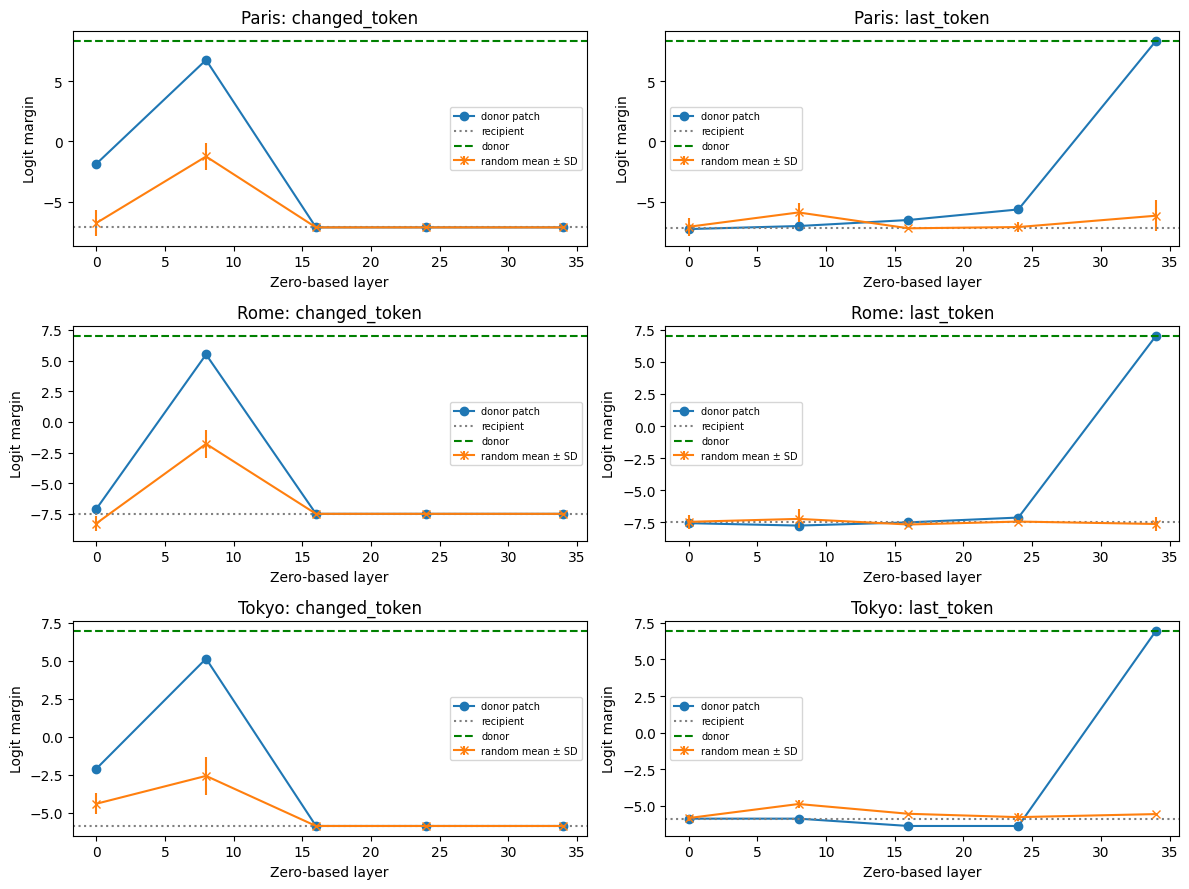

,donor answer,recipient answer,layer,position,margin,recovery ratio,top1,donor answer is top1,random mean margin,trivial final-readout control
0,Paris,Berlin,0,changed_token,-1.8750,0.340081,Berlin,False,-6.770833,False
1,Paris,Berlin,0,last_token,-7.2500,-0.008097,Berlin,False,-7.062500,False
2,Paris,Berlin,8,changed_token,6.7500,0.898785,Paris,True,-1.250000,False
3,Paris,Berlin,8,last_token,-7.0000,0.008097,Berlin,False,-5.875000,False
4,Paris,Berlin,16,changed_token,-7.1250,0.000000,Berlin,False,-7.125000,False
5,Paris,Berlin,16,last_token,-6.5000,0.040486,Berlin,False,-7.187500,False
6,Paris,Berlin,24,changed_token,-7.1250,0.000000,Berlin,False,-7.125000,False
7,Paris,Berlin,24,last_token,-5.6250,0.097166,Berlin,False,-7.083333,False
8,Paris,Berlin,34,changed_token,-7.1250,0.000000,Berlin,False,-7.125000,False
9,Paris,Berlin,34,last_token,8.3125,1.000000,Paris,True,-6.145833,True


Self-patch max errors: [[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0]]


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
rows = []
for row, pair in enumerate(report["pairs"]):
    for col, position in enumerate(["changed_token", "last_token"]):
        entries = [r for r in pair["patches"] if r["position_name"] == position]
        layers = [r["layer"] for r in entries]
        axes[row, col].plot(layers, [r["margin"] for r in entries], marker="o", label="donor patch")
        axes[row, col].errorbar(layers,
            [np.mean(r["random_margins"]) for r in entries],
            yerr=[np.std(r["random_margins"], ddof=1) for r in entries],
            marker="x", label="random mean ± SD")
        axes[row, col].axhline(pair["recipient_margin"], color="gray", linestyle=":", label="recipient")
        axes[row, col].axhline(pair["clean_margin"], color="green", linestyle="--", label="donor")
        axes[row, col].set_title(pair["target"].strip() + ": " + position)
        axes[row, col].set_xlabel("Zero-based layer"); axes[row, col].set_ylabel("Logit margin")
        axes[row, col].legend(fontsize=7)
    for entry in pair["patches"]:
        rows.append({"donor answer": pair["target"], "recipient answer": pair["foil"],
            "layer": entry["layer"], "position": entry["position_name"],
            "margin": entry["margin"], "recovery ratio": entry["recovery_ratio"],
            "top1": entry["top_token"], "donor answer is top1": entry["top_token_id"] == pair["target_id"],
            "random mean margin": np.mean(entry["random_margins"]),
            "trivial final-readout control": entry["trivial_final_readout_control"]})
plt.tight_layout(); plt.show()
with pd.option_context("display.max_rows", 40):
    display(pd.DataFrame(rows))
print("Self-patch max errors:", [[c["max_logit_error"] for c in p["self_controls"]] for p in report["pairs"]])


## 6. Inspect all numerical evidence and limitations

A changed logit margin is not sufficient for selective, generalizable control. Look at the entire vocabulary's top-1 result, the random controls and examples that fail. Three factual contrasts do not establish a universal knowledge circuit.

The reproducible CLI report is committed at `examples/outputs/gemma4_pretrained.json`. The expandable object here is from **this notebook's actual execution**, not loaded from that saved report. Fitted pretrained J-lens, SAE dictionaries, and circuit-transcoder analyses are separate future examples, not implied by this notebook.

In [7]:
display(JSON(report, expanded=False))
rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
rss_mib = rss / (1024**2 if sys.platform == "darwin" else 1024)
print(json.dumps({
    "tutorial_compute_wall_seconds": round(time.perf_counter() - started, 3),
    "kernel_lifetime_peak_rss_mib": round(rss_mib, 2),
    "memory_scope": "kernel only, includes CPU embedding table and imports; not aggregate system memory",
    "gpu_peak_allocated_gib": round(torch.cuda.max_memory_allocated()/1024**3, 3),
    "gpu_peak_reserved_gib": round(torch.cuda.max_memory_reserved()/1024**3, 3)
}))


<IPython.core.display.JSON object>

{"tutorial_compute_wall_seconds": 9.578, "kernel_lifetime_peak_rss_mib": 6451.43, "memory_scope": "kernel only, includes CPU embedding table and imports; not aggregate system memory", "gpu_peak_allocated_gib": 4.296, "gpu_peak_reserved_gib": 4.338}
